# Pipeline PySpark local — Fruits!

**Objectif** : reproduire, comprendre et le cas échéant corriger la chaîne de traitement développée par l'alternant (voir `P8_Mode_opératoire/`), puis la compléter avec une étape de réduction de dimension par PCA en PySpark.

> Travail sur un échantillon de taille adapté au travail en local (`data/sample`, 10 classes x 30 images, généré par `scripts/prepare_sample.py`) avant tout passage à l'échelle sur AWS EMR.


# 1. Chargement des données

## Imports

In [1]:
import os

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, element_at, split

## Définition des chemins

In [2]:
# pour la portabilité du code en mode local, recherhce dans le répertoire courant et ses parents jusqu'à trouver le fichier `requirements.txt`
# inutile pour le script cloud, car on définira le path par une variable 

def find_project_root(marker: str = "requirements.txt") -> str:
    """Walk up from the current working directory until `marker` is found."""
    current_dir = os.getcwd()
    while not os.path.exists(os.path.join(current_dir, marker)):
        parent_dir = os.path.dirname(current_dir)
        if parent_dir == current_dir:
            raise FileNotFoundError(f"Could not locate project root (marker: {marker})")
        current_dir = parent_dir
    return current_dir


PROJECT_ROOT = find_project_root()
PATH_DATA = os.path.join(PROJECT_ROOT, "data", "sample")
PATH_RESULT = os.path.join(PROJECT_ROOT, "results")

print(f"PATH_DATA:   {PATH_DATA}")
print(f"PATH_RESULT: {PATH_RESULT}")

PATH_DATA:   /Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample
PATH_RESULT: /Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/results


## Sparksession

### Notes - Sparks

**A. But et Fonctionnement de Spark**
Spark est un moteur de calcul distribué. Une "application Spark" est composée de 4 types d'acteurs/processus :

- *un driver program* qui est le processus qui pilote l'exécution, construit le plan de calcul et coordonne les tâches (*tasks*) ;
- un *cluster manager* qui sert d'intermédiaire entre le *driver program* et les machines physqiues (en local, ce rôle est implicite ; sur AWS-EMR, ce sera YARN)  ;
- *des workers node*  qui sont les machines ud clusteret qui mettent à dispositions les ressources nécessaires à l'exécution 
- *des executors* qui exécutent réellement le travail, les *tasks* sur les partitions de données .

**B. Définition des termes**
- *Driver program* : le processus qui exécute la fonction principale de votre application et crée le SparkContext.
- *Cluster manager* : le service externe qui négocie et alloue les ressources du cluster au driver (Standalone manager, YARN, Mesos, Kubernetes..) ; le driver ne parle jamais directement aux worker nodes, il passe par le cluster manager pour obtenir les ressources.
- *Worker node* : une machine du cluster qui a des ressources disponibles (CPU, mémoire) pour exécuter les tasks. 
- *Executor* : un processus (une JVM) lancé sur un worker node, dédié à une application Spark précise. C'est lui qui exécute réellement les tâches et garde les données en cache.
- *Task* : une unité de travail envoyée à un executor — concrètement, l'application d'une opération sur une seule partition de données. Un executor exécute généralement plusieurs tasks, souvent une par cœur/thread dont il dispose.

*Source : https://spark.apache.org/docs/latest/cluster-overview.html*

**C. Mode local**

**Ici, nous codons et exécutons la partie ***driver program*** : nous décrivons le calcul à Spark qui se charge de le distribuer.**

- En mode local[*], il n'y a pas de vrais processus séparés. Driver et executor tournent dans la même JVM, l'unique processus Python/Java lancé quand on exécutera la cellule SparkSession.builder...getOrCreate(). 
- Le parallélisme ne vient pas de plusieurs machines ou processus, mais de ***threads*** à l'intérieur de ce processus unique 
> local[*] demande à Spark d'utiliser autant de threads que de cœurs disponibles sur note machine. C'est une simulation de cluster.

**D. Sur AWS EMR**


Il s'agit d'un réel cluster de machines distinctes, dont le ***découpage*** est le suivant :

- Le *nœud primaire* (une instance EC2 dédiée) héberge le driver, ainsi que le gestionnaire de ressources YARN (le système qui décide où placer le travail sur le cluster) ; EMR utilise YARN comme gestionnaire de cluster par défaut.
- Les **nœuds core et task* (d'autres instances EC2) hébergent quant à eux les *executors*, chacun tournant dans un *conteneur YARN* (une tranche isolée de CPU/mémoire allouée par YARN sur cette machine). Une même machine peut héberger plusieurs conteneurs/executors selon les ressources disponibles et la configuration.

> La différence entre nœuds core et task : les *nœuds core* stockent aussi des données (HDFS), les *nœuds task* ne font qu'exécuter le calcul, ce qui les rend éligibles aux *instances spot* (moins chères) puisqu'ils ne conservent pas de données permanentes.

> le code Python développé ici ne change donc pas entre le mode local ou le mode cloud, seul .master(..) diffère. Cependant les processus machines en arrière-plan sont différents : threads dans un seul processus en local, contre plusieurs machines et processus JVM séparés sur EMR.

**E. La SparkSession**

***La SparkSession n'est pas un acteur en soi***, ni le cluster manager, ni un worker node, ni un executor. **C'est l'interface du driver program**, l'objet python qu'on manipule pour piloter tout le reste.


Concrètement, quand nous exécutons :

> spark = SparkSession.builder.appName("P11_Fruits").master("local[*]").getOrCreate()

on initialise le driver program. Sur un vrai cluster, cela déclencherait le contact avec le *cluster manager* pour négocier des ressources et obtenir des *executors*. En local, cette ligne met en place le pool de *threads* simulant le cluster.


**SparkSession unifie et encapsule plusieurs objets en un seul point d'entrée :**
- un ***SparkContext*** pour parler au cluster manager et manipuler les RDD (la structure de données bas niveau de Spark);
- un ***SQLContext*** pour les DataFrames et le SQL, 
- un ***HiveContext*** (maintenant obsolète) qui permettait à Spark de lire et d'écrire des tables Hive et d'exécuter des requêtes en HiveQL, pour l'intégration Hive, un système d'entrepôt de données permettant d'interroger de gros volumes de fichiers distribués avec un langage proche du SQL (HiveQL).


> sc = spark.sparkContext permet donc de récupérer cet objet bas niveau, toujours accessible depuis la session, car certaines opérations d'historiques comme sc.broadcast(..), sont définies sur le SparkContext, pas directement sur SparkSession.

**Synthèse** 

***La SparkSession est l'orchestrateur du driver program***, le seul objet dont on a besoin dans votre code pour déclencher tout ce qui se passe ensuite avec le cluster manager, les worker nodes et les executors, sans jamais avoir à les manipuler nous-même.



In [3]:
# création de la sparksession
spark = (
    SparkSession.builder
    .appName("P11_Fruits") # nom visible dans le spark UI et les logs EMR
    .master("local[*]") # définition du mode d'éxéctuion,  en local avec tous les cœurs disponibles, différent pour l'EMR
    .config("spark.sql.parquet.writeLegacyFormat", "true") # lié au choix du format de sortie (parquet)
    .getOrCreate()
)
# récupération du sparkContext pour sc.broadcast(...) en section 2
sc = spark.sparkContext

# affichage du résumé de session : lien vers la Spark UI, version, master, appName
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/25 18:12:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Récupération des images au format binaire

- **`spark.read.format("binaryFile")`** charge chaque image comme une ligne contenant ses métadonnées (chemin, date de modification,  taille et contenu brut en bytes) pas de décodage à ce stade. le prétraitement (redimensionnement, normalisation) sera fait à l'étape de featurisation, où il sera appliqué en parallèle sur chaque partition.

- **`recursiveFileLookup`** parcourt tous les sous-dossiers de `data/sample` précédemment créé avec le script prepare_sample.py et contenant un sous-dossier par classe. 

- **`pathGlobFilter`** ne garde que les `.jpg`.

In [4]:
images = (
    spark.read.format("binaryFile")
    .option("pathGlobFilter", "*.jpg")
    .option("recursiveFileLookup", "true")
    .load(PATH_DATA)
)

images.printSchema()
images.select("path", "length").show(5, truncate=False)

root
 |-- path: string (nullable = true)
 |-- modificationTime: timestamp (nullable = true)
 |-- length: long (nullable = true)
 |-- content: binary (nullable = true)

+-----------------------------------------------------------------------------------------------------------------------------------------+------+
|path                                                                                                                                     |length|
+-----------------------------------------------------------------------------------------------------------------------------------------+------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/10_100.jpg|6168  |
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/14_100.jpg|6151  |
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_1

## Extraction du label

Il n'y a pas de colonne "label" dans les données brutes : la classe de chaque image est encodée dans son chemin (`.../data/sample/Apricot/0_100.jpg` => label `Apricot`). `split(path, '/')` découpe donc le chemin en une liste de segments, et prend l'avant-dernier élément avec `element_at(..., -2)`, qui est le nom du dossier parent de l'image. 

In [5]:
images = images.withColumn("label", element_at(split(col("path"), "/"), -2))

images.select("path", "label").show(5, truncate=False)
images.groupBy("label").count().show()

+-----------------------------------------------------------------------------------------------------------------------------------------+----------------+
|path                                                                                                                                     |label           |
+-----------------------------------------------------------------------------------------------------------------------------------------+----------------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/10_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/14_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/11_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MA

# 2. Préparation et utilisation d'un modèle pré-entraîné

### Notes - Choix du modèle et de la stratégie d'apprentissage

- Les limitations de ce projet sont claires : nous devons mettre en place la chaîne de traitement (preprocessing + réduction de dimension) qui servira plus tard à un moteur de classification. Il n'est pas demandé d'entrainer un modèle de classification pour l'instant.

- On a donc besoin, pour chaque image, d'un **vecteur de caractéristiques**, l'empreinte numérique résumant son contenu visuel, et pas d'une prédiction de classe.

- Le **transfer learning** permet d'obtenir ce *vecteur* sans rien entraîner : on réutilise sur nos données un réseau déjà entraîné et on récupère la sortie de son **avant-dernière couche** qui contient le vecteur dense plutôt que sa couche finale, celle de la classification inutile ici. 

**MobileNetV2 entraîné sur ImageNet** est choisi pour deux raisons pratiques : 
- c'est un modèle léger et rapide ;
- son vecteur dense de sortie à 1280 dimensions, qui encode les caractéristiques visuelles de l'image, est déjà relativement compact comparé à d'autres architectures, ce qui en fait un bon point de départ avant la PCA de la section 4.


## Imports

In [6]:
from tensorflow.keras import Model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2


2026-07-25 18:13:01.310324: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Construction du modèle

In [7]:
# instanciation du modèle mobilenetv2 pré-entraîné sur ImageNet, avec la couche de sortie (top) incluse
base_model = MobileNetV2(
    weights="imagenet",
    include_top=True,
    input_shape=(224, 224, 3),
)

# reconstruction d'un modèle dont la sortie est l'avant-dernière couche (= levecteur de 1280 caractéristiques), sans la couche de classification finale
feature_model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
# vérifie la shape de la sortie = un vecteur (1, 1, 1280)
feature_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Broadcast des poids du modèle

### Notes - Utilisation du broadcast des poids du modèle (diffusion) 

- Sur le même principe de driver/workers utilisé pour les images, on diffuse (broadcast) ici les poids du modèle plutot que le modèle lui-même.
- **`feature_model`** est un objet complexe python (graphe de calcul Tensorflow) : il n'est pas conçu pour être sérialisé et envoyé tel quel à chaque processus (Python worker) pour chaque task.

- ICi, chaque processus **reconstruit lui-même l'architecture** du modèle (quelques lignes de code, peu coûteux), puis se voit attribuer les **poids déjà entraînés** via un mécanisme de diffusion encapsulé dans Spark. 

- Le ***broadcast copie une seule fois et diffuse une donnée vers chaque machine du cluster***, sans devoir donc répété l'opération pour chacune des taches de chaque machine du cluster. La donnée reste en cache ce qui est un processus plus efficace que de la retransmettre à chaque appel.

**Retour critique demandé sur le travail de l'alternant** 
- ***Rebondance repérée dans le notebook P8_Notebook_Linux_EMR_PySpark_V1.0.ipynb*** => `model_fn()` utilisait initialement `weights="imagenet"` pour reconstruire l'architecture.

- Cette action charge à nouveau les poids ImageNet complets sur chaque processus (Python worker), juste avant de les écraser avec le broadcast des poids prévu juste après `model.set_weights(broadcast_weights.value)`. 

- ***Cette redondance va à l'encontre de l'intérêt du broadcast*** : elle refait, sur chaque processus (Python worker), le travail de chargement que la diffusion des poids est censée éviter.

- ***Correction avec `weights=None`*** qui reconstruit uniquement l'architecture sans charger les poids, car `set_weights()` injecte les poids diffusés juste après. ***Le résultat final est identique, mais sans le chargement redondant.***


In [8]:
broadcast_weights = sc.broadcast(feature_model.get_weights())


def model_fn():
    """Rebuild the MobileNetV2 feature-extraction model and load the broadcasted weights.

    Called once per worker (not once per image), so the model is reconstructed
    only a handful of times regardless of how many images are processed.
    """
    # architecture seule : les poids sont injectés juste après via broadcast_weights
    base = MobileNetV2(weights=None, include_top=True, input_shape=(224, 224, 3))
    for layer in base.layers:
        layer.trainable = False
    model = Model(inputs=base.input, outputs=base.layers[-2].output)
    # récupération des poids du modèle pré-entraîné via broadcast_weights
    model.set_weights(broadcast_weights.value)
    return model

# 3. Featurisation via pandas UDF

### Notes - Stratégie de featurisation : pandas UDF Scalar Iterator

- La featurisation est le processus qui extrait les features des données brutes. Ici, cette tâche est accomplie par le modèle.

- Spark fournit une grande bibliothèque de fonctions intégrées, reconnues nativement par le moteur d'optimisation de Spark (Catalyst), et exécutées efficacement dans la JVM. Cependant si on abesoin d'une fonction non proposée nativement dans Spark, on peut la définir avec une UDF pour qu'elle puisse être appelée lors des traitements exécutés sur le dataframe des données.

- Spark propose plusieurs variantes de performance pour les **UDF** : 
  - UDF classique ligne par ligne (très lent) ;
  - **Pandas UDF vectorisée par lots**, qui permet d'envoyer des lots de ligne (pandas.Series) via Arrow (format d'échange mémoire optimisé), et traite donc le lot en une fois pour renvoyer le résultat en bloc. 

- La variante **Scalar Iterator de pandas UDF** (`PandasUDFType.SCALAR_ITER`) va plus loin : au lieu de recevoir un seul lot, la fonction reçoit un **itérateur de lots**. Cela permet d'appeler `model_fn()` **une seule fois par worker**, avant de traiter tous les lots qui lui sont confiés, plutôt que de reconstruire le modèle à chaque lot. Cela représente un gain de ressources important quand on traite des milliers d'images.

***La pile d'appels est la suivante :***
- `featurize_udf` (pandas UDF Scalar Iterator) — charge le modèle une fois
  - `featurize_series` — featurise un lot d'images (`pd.Series`)
    - `preprocess` — décode et prétraite une image individuelle

## Imports

In [9]:
import io

import numpy as np
import pandas as pd
from PIL import Image
from pyspark.sql.functions import PandasUDFType, pandas_udf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array


## Fonctions pour la chaîne de featurisation

In [10]:
# préprocessing adapté au modèle MobileNetV2
def preprocess(content: bytes) -> np.ndarray:
    """Decode raw JPEG bytes and prepare a single image for MobileNetV2."""
    img = Image.open(io.BytesIO(content)).resize([224, 224]) # taille attendue
    arr = img_to_array(img) # conversion de PIL.Image en np.ndarray float32
    return preprocess_input(arr)

# applique le modèle sur tout le batch => featurise un lot d'images en une seule fois
def featurize_series(model: Model, content_series: pd.Series) -> pd.Series:
    """Featurize a batch of raw images using the given model."""
    input_batch = np.stack(content_series.map(preprocess)) # applique le preprocess à chaque image du lot, puis empile le tout en un seul batch numpy
    preds = model.predict(input_batch) # inférence sur tout le batch en une fois
    output = [p.flatten() for p in preds] # aplatit chaque sortie en un vecteur simple
    return pd.Series(output) # reconversion en pandas.Series attendu en sortie d'une pandas UDF

# pandas UDF Scalar Iterator : reconstruit le modèle une seule fois par worker, puis featurise chaque lot d'images qu'on lui a confié
@pandas_udf("array<float>", PandasUDFType.SCALAR_ITER) # déclare le type de retour (tableau de float) et le type de pandas UDF (Scalar Iterator)
def featurize_udf(content_series_iter):
    """Scalar Iterator pandas UDF: loads the model once, then reuses it across batches."""
    model = model_fn()
    for content_series in content_series_iter:
        yield featurize_series(model, content_series)

/opt/anaconda3/envs/env_p11_chantepie/lib/python3.10/site-packages/pyspark/sql/pandas/functions.py:761: UserWarning: In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(


## Exécution 

- **`repartition(n)`** redécoupe le df en `n` partitions avant la featurisation. Cela permet de s'assurer que le travail est bien réparti entre tous les workers disponibles, car par défaut le nombre de partitions faites dépend du nombre de fichiers/blocs sources, ce n'est pas optimal ici. Nous restons volontairement modeste ici pour notre échantillon de 300 images, avec n=8 .

> - mon Mac a 8 cœurs physiques et 16 cœurs logiques. avec seulement 8 partitions, on utilise seulement et au maximum que 8 de ces 16 threads simultanément. 
> - Ce chiffre n'a de sens que pour le petit échantillon en local => sur EMR, il faudra le recalculer en fonction du nombre réel d'executors et de cœurs disponibles sur le cluster, ainsi que du volume de données à traiter. 
> - n=8 n'est donc pas une valeur à reporter telle quelle à l'échelle.

**Pourquoi `.persist()` ?** 
- Spark est en mode *lazy* : sans le persist(), chaque action ultérieure sur `features_df` (la PCA, l'écriture finale, etc.) redéclencherait tout le calcul depuis le début. Cela incluerait la featurisation par MobileNetV2, l'étape la plus coûteuse du pipeline. 
- Le `.persist()` demande donc à Spark de garder le résultat en cache (ou sur disque si besoin) après le premier calcul, pour le réutiliser tel quel dans les étapes suivantes.

In [11]:
features_df = images.repartition(8).select(
    col("path"),
    col("label"),
    featurize_udf("content").alias("features"),
)

features_df.persist()
print(f"Nombre d'images featurisées : {features_df.count()}")
features_df.select("path", "label").show(5, truncate=False)

2026-07-25 18:13:11.790945: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-25 18:13:11.790996: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-25 18:13:11.807817: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-25 18:13:11.820952: I tensorflow/core/platform/cpu_featu

Nombre d'images featurisées : 300
+------------------------------------------------------------------------------------------------------------------------------------------+----------------+
|path                                                                                                                                      |label           |
+------------------------------------------------------------------------------------------------------------------------------------------+----------------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/162_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/172_100.jpg|Strawberry Wedge|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/data/sample/Strawberry Wedge/157_100.jpg|Strawberry Wedge|
|file:/Users/steph

# 4. Réduction de dimension avec PCA PySpark

## Notes - Choix PCA en PySpark 

- Le vecteur de sortie de MobileNetV2 a 1280 dimensions. C'est déjà beaucoup plus compact qu'une image brute, mais ça reste volumineux à grande échelle : le dataset fruits-360 complet compte déjà *90 483 images (131 classes)*. c'est déjà bien plus que les 22 688 images du seul dossier Test utilisées par l'alternant pour sa démonstration cloud. on sait également que ce volume est amené à augmenter encore avec la mise à l'échelle annoncée. Stocker et manipuler des vecteurs à 1280 dimensions par image, à cette échelle, a un coût de stockage et de calcul non négligeable pour le futur moteur de classification.

- La **PCA Principal Component Analysis** réduit cette dimensionnalité en ne gardant que les axes qui expliquent le plus de variance dans les données, afin de perdre le moins d'information possible.

- Une implémentation scikit-learn est souvent utilisée pour faire une PCA. **Cependant son fonctionnement ne sera pas compatible avec la philosophie de distribution qui oriente ce projet.** En effet scikit-learn doit recevoir l'intégralité de la matrice de données **en mémoire, sur une seule machine**. Ça fonctionne pour 300 images, mais la mémoire nécessaire augmente de manière linéairement avec le nombre d'images (et l'augmentation du volume des données est annoncée). au-delà d'un certain volume (des millions d'images, selon la RAM disponible), ça devient impossible sur une seule machine, cela referait un goulet d'étranglement séquentiel là où Spark est utiliser pour distribuer les différentes tâches.

**La PCA de pyspark**

`pyspark.ml.feature.PCA` est conçue différemment, on y retrouve le principe driver/workers :
1. *Chaque worker* calcule, sur sa partition, une contribution à la **matrice de covariance** (une matrice `1280 × 1280` => donc sa taille ne dépend donc pas du nombre d'images, mais du nbre de dimensions).
2. ***à la fin des opérations de distributions, les contributions sont agrégées pour obtenir la matrice de covariance complète.***
3. Cette *matrice*, petite et fixe en taille, est ensuite décomposée (calcul des vecteurs propres) **en une seule fois sur le driver program**. ***le calcul est donc centralisé en local mais peu coûteux***, car il ne dépend que du nombre de dimensions (1280), jamais du nombre de lignes.
4. Chaque ligne du jeu de données est ensuite projetée sur les nouveaux axes, lors d'une opération également distribuée, appliquée en parallèle par les workers.

> Le calcul lourd (parcourir toutes les images) est distribué ; le calcul fin (décomposition) reste centralisé mais reste modeste quel que soit le volume de données. C'est ce qui permet à la PCA de "passer à l'échelle" avec le volume de données final prévu pour ce projet.

## Notes - Préparation avant PCA 

Deux étapes sont préalables et obligatoires *avant* d'appliquer la PCA de `pyspark.ml` :

1. **Conversion de type du tableau au vecteur** : `featurize_udf` renvoie une colonne `array<float>` (un simple tableau), mais les algorithmes de `pyspark.ml` attendent un type `Vector`. `array_to_vector` fait cette conversion.

2. **Centrage-réduction (`StandardScaler`)** : la PCA cherche les axes de variance maximale. Si les données ne sont pas centrées sur 0, le premier axe trouvé aura tendance à capturer surtout la moyenne des données plutôt que leur variabilité réelle, ce qui fausse le résultat. De la même façon, sans une mise à l'échelle par une réduction, une dimension à plus grande variance brute dominerait artificiellement l'axe principal trouvé, même si elle n'apporte pas d'informations que les autres. Il s'agit d'un rappel, cette une étape standard systématiquement recommandée avant toute PCA.

## Imports

In [ ]:
from pyspark.ml.feature import PCA, StandardScaler
from pyspark.ml.functions import array_to_vector
import matplotlib.pyplot as plt

## Préparation des données 

In [14]:
# conversion en Vector 
vector_df = features_df.select(
    "path",
    "label",
    array_to_vector("features").alias("features_vec"),
)

# centrage-réduction
scaler = StandardScaler(
    inputCol="features_vec",
    outputCol="scaled_features",
    withMean=True,
    withStd=True,
)
scaler_model = scaler.fit(vector_df) # calcule moyenne et écart-type sur les données (opération distribuée)
scaled_df = scaler_model.transform(vector_df) # applique la transformation à chaque ligne

# aperçu
scaled_df.select("path", "label", "scaled_features").show(3, truncate=80) 

+--------------------------------------------------------------------------------+----------------+--------------------------------------------------------------------------------+
|                                                                            path|           label|                                                                 scaled_features|
+--------------------------------------------------------------------------------+----------------+--------------------------------------------------------------------------------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry Wedge|[0.03407200743297145,-0.7058729283341508,-0.3849294075632169,-0.3859354047247...|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry Wedge|[-0.4071324345362666,-0.47160315487568183,-0.3849294075632169,-0.385935404724...|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry We

### Notes - Nombre de composantes (k)

- Il n'y a pas de "bon k" universel : c'est un compromis entre compression et perte d'information, à arbitrer au cas par cas. en regardant la **variance expliquée cumulée**, on choisira un k plus adapté. On commence ici par une PCA avec un `k` volontairement grand : `k=100`, sur seulement 300 images et 10 classes. cela va nous permettre d'observer la courbe de variance expliquée, puis de choisir un `k` plus petit en fonction de ce qu'elle montre.

**Point de vigilance pour la suite du projet** : ce choix de `k` est fait ici sur un échantillon de 10 classes non représentatif du jeu de données complet (131 classes). Il faudra le revalider sur le jeu de données complet une fois sur EMR — la variance expliquée par un même `k` peut différer significativement selon la diversité des images.

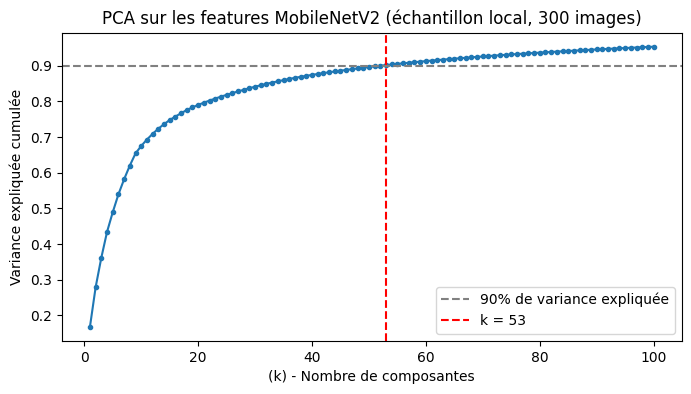

In [16]:
pca_explore = PCA(k=100, inputCol="scaled_features", outputCol="pca_features_full")
pca_explore_model = pca_explore.fit(scaled_df)

explained_variance = pca_explore_model.explainedVariance.toArray()
cumulative_variance = np.cumsum(explained_variance)
k_90 = int(np.argmax(cumulative_variance >= 0.90) + 1)  # abscisse du croisement avec les 90%

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", markersize=3)
plt.axhline(0.90, color="gray", linestyle="--", label="90% de variance expliquée")
plt.axvline(k_90, color="red", linestyle="--", label=f"k = {k_90}")  
plt.xlabel("(k) - Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("PCA sur les features MobileNetV2 (échantillon local, 300 images)")
plt.legend()
plt.show()

In [17]:
print(f"Composantes nécessaires pour 90% de variance expliquée : {k_90}")
print(f"Variance expliquée avec {k_90} composantes : {cumulative_variance[k_90 - 1]:.4f}")

Composantes nécessaires pour 90% de variance expliquée : 53
Variance expliquée avec 53 composantes : 0.9012


In [18]:
# réajustement de la PCA avec la valeur k pour laquelle on obtient 90% de variance expliquée
pca = PCA(k=k_90, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_df)
pca_df = pca_model.transform(scaled_df)

pca_df.select("path", "label", "pca_features").show(3, truncate=80)

+--------------------------------------------------------------------------------+----------------+--------------------------------------------------------------------------------+
|                                                                            path|           label|                                                                    pca_features|
+--------------------------------------------------------------------------------+----------------+--------------------------------------------------------------------------------+
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry Wedge|[-5.287437330475509,0.9938178276457581,20.97620808692644,6.498999952806434,-3...|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry Wedge|[-2.5941090307530086,0.32458644373422624,19.85911016635906,7.739687193770584,...|
|file:/Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/ope...|Strawberry We

# 5. Sauvegarde et validation des résultats de la pipeline

## Notes - Format de sauvegarde des résultats > la matrice des vecteurs features réduits avec la PCA

Le format **Parquet** est conservé plutôt que CSV (format donné en exemple mais non imposé) pour plusieurs raisons :
- c'est le **format natif de Spark** : il gère nativement les colonnes de type `Vector`/`array` (comme `pca_features`), alors que le CSV est purement tabulaire et aurait exigé d'aplatir le vecteur en autant de colonnes que de composantes (`pca_0`, `pca_1`, ..., `pca_52`) ;
- il est **auto-descriptif** (schéma et types conservés à l'écriture), ce qui évite les erreurs de parsing à la relecture ;
- il prolonge la démarche de l'alternant, qui écrivait déjà en parquet.

> un fichier parquet nécessite `pandas` + `pyarrow` pour être ouvert

- **`vector_to_array`** reconvertit la colonne `Vector` en simple tableau avant écriture : plus portable pour la lecture ultérieure hors Spark (ici avec `pandas.read_parquet`), qui n'exploite pas nativement le type `Vector`.

- on conserve seulement le path, les label et les pca_features. on ne conserve pas le vecteur à 1280 dimensions non réduit dans le résultat final, car ce n'est pas utile pour la suite des traitements

## Imports

In [19]:
from pyspark.ml.functions import vector_to_array

## Sauvegarde des résultats

In [20]:
result_df = pca_df.select(
    "path",
    "label",
    vector_to_array("pca_features").alias("pca_features"),
)

result_df.write.mode("overwrite").parquet(PATH_RESULT)
print(f"Résultats sauvegardésdans {PATH_RESULT}")

26/07/25 19:18:22 WARN MemoryManager: Total allocation exceeds 95,00% (1 020 054 720 bytes) of heap memory
Scaling row group sizes to 95,00% for 8 writers


Résultats sauvegardésdans /Users/stephanieduhem/Documents/_DIPLOMES_CURSUS_/MASTER_AI_ENGINEER/openclassroom/projet_11/results


## Validation

> - d'abord on charge les résultats avec pandas (hors Spark, comme le ferait un utilisateur en aval de ce pipeline) 
> - Puis on vérifie que la dimension du vecteur correspond bien à `k_90`
> - Enfin on estime le gain de compression obtenu par la PCA.

In [21]:
validation_df = pd.read_parquet(PATH_RESULT, engine="pyarrow")

print(validation_df.head())
print(f"\nDimension du vecteur PCA : {validation_df.loc[0, 'pca_features'].shape}")

original_dim = 1280
reduced_dim = k_90
reduction_pct = 100 * (1 - reduced_dim / original_dim)
print(f"\nRéduction de dimension : {original_dim} -> {reduced_dim} ({reduction_pct:.1f}% de moins)")

                                                path             label  \
0  file:/Users/stephanieduhem/Documents/_DIPLOMES...  Strawberry Wedge   
1  file:/Users/stephanieduhem/Documents/_DIPLOMES...  Strawberry Wedge   
2  file:/Users/stephanieduhem/Documents/_DIPLOMES...  Strawberry Wedge   
3  file:/Users/stephanieduhem/Documents/_DIPLOMES...             Guava   
4  file:/Users/stephanieduhem/Documents/_DIPLOMES...             Guava   

                                        pca_features  
0  [-5.287437330475509, 0.9938178276457581, 20.97...  
1  [-2.5941090307530086, 0.32458644373422624, 19....  
2  [-5.224705457906081, 1.0375195715629957, 19.60...  
3  [-4.891880303929059, -7.5702791631416995, 4.84...  
4  [-6.323576325095195, -8.627868361164134, 3.570...  

Dimension du vecteur PCA : (53,)

Réduction de dimension : 1280 -> 53 (95.9% de moins)
